# Clasificador de Sentimientos con RNN — PyTorch

Este notebook implementa una RNN many-to-one para clasificar frases como **positivas** o **negativas**.



## 1. Imports

In [ ]:
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Reproducibilidad
torch.manual_seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {device}')

Usando: cpu


## 2. Datos

Frases etiquetadas como `True` (positivo) o `False` (negativo).

In [ ]:
train_data = {
    'good': True, 'bad': False, 'happy': True, 'sad': False,
    'not good': False, 'not bad': True, 'not happy': False, 'not sad': True,
    'very good': True, 'very bad': False, 'very happy': True, 'very sad': False,
    'i am happy': True, 'this is good': True, 'i am bad': False, 'this is bad': False,
    'i am sad': False, 'this is sad': False, 'i am not happy': False,
    'this is not good': False, 'i am not bad': True, 'this is not sad': True,
    'i am very happy': True, 'this is very good': True, 'i am very bad': False,
    'this is very sad': False, 'this is very happy': True, 'i am good not bad': True,
    'this is good not bad': True, 'i am bad not good': False,
    'i am good and happy': True, 'this is not good and not happy': False,
    'i am not at all good': False, 'i am not at all bad': True,
    'i am not at all happy': False, 'this is not at all sad': True,
    'this is not at all happy': False, 'i am good right now': True,
    'i am bad right now': False, 'this is bad right now': False,
    'i am sad right now': False, 'i was good earlier': True,
    'i was happy earlier': True, 'i was bad earlier': False, 'i was sad earlier': False,
    'i am very bad right now': False, 'this is very good right now': True,
    'this is very sad right now': False, 'this was bad earlier': False,
    'this was very good earlier': True, 'this was very bad earlier': False,
    'this was very happy earlier': True, 'this was very sad earlier': False,
    'i was good and not bad earlier': True,
    'i was not good and not happy earlier': False,
    'i am not at all bad or sad right now': True,
    'i am not at all good or happy right now': False,
    'this was not happy and not good earlier': False,
}

test_data = {
    'this is happy': True, 'i am good': True, 'this is not happy': False,
    'i am not good': False, 'this is not bad': True, 'i am not sad': True,
    'i am very good': True, 'this is very bad': False, 'i am very sad': False,
    'this is bad not good': False, 'this is good and happy': True,
    'i am not good and not happy': False, 'i am not at all sad': True,
    'this is not at all good': False, 'this is not at all bad': True,
    'this is good right now': True, 'this is sad right now': False,
    'this is very bad right now': False, 'this was good earlier': True,
    'i was not happy and not good earlier': False,
}

print(f'Frases de entrenamiento: {len(train_data)}')
print(f'Frases de prueba:        {len(test_data)}')

# Distribución de clases
pos_train = sum(1 for v in train_data.values() if v)
neg_train = len(train_data) - pos_train
print(f'\nTrain — Positivas: {pos_train} | Negativas: {neg_train}')

Frases de entrenamiento: 58
Frases de prueba:        20

Train — Positivas: 26 | Negativas: 32


## 3. Vocabulario y representación One-Hot

Cada palabra se convierte en un vector de ceros con un solo `1` en la posición que le corresponde.

```
"good"  →  [0, 0, 1, 0, 0, ...]   (vocab_size,)
"happy" →  [0, 1, 0, 0, 0, ...]   (vocab_size,)
```

Una frase de N palabras produce N vectores: `(N, vocab_size)`

In [ ]:
all_texts = list(train_data.keys()) + list(test_data.keys())
vocab = sorted(set(w for text in all_texts for w in text.split()))
vocab_size = len(vocab)
word_to_idx = {w: i for i, w in enumerate(vocab)}

print(f'{vocab_size} palabras únicas: {vocab}')


def text_to_tensor(text: str) -> torch.Tensor:
    """
    Convierte texto a secuencia de vectores one-hot.
    Retorna tensor de forma (seq_len, vocab_size).
    """
    words = text.split()
    one_hots = torch.zeros(len(words), vocab_size)
    for i, w in enumerate(words):
        one_hots[i, word_to_idx[w]] = 1.0
    return one_hots


# Ejemplo
ejemplo = 'not good'
t = text_to_tensor(ejemplo)
print(f'\n"{ejemplo}" → tensor shape: {t.shape}')
print(f'Palabra "not"  → índice {word_to_idx["not"]} → vector: {t[0].int().tolist()}')
print(f'Palabra "good" → índice {word_to_idx["good"]} → vector: {t[1].int().tolist()}')

18 palabras únicas: ['all', 'am', 'and', 'at', 'bad', 'earlier', 'good', 'happy', 'i', 'is', 'not', 'now', 'or', 'right', 'sad', 'this', 'very', 'was']

"not good" → tensor shape: torch.Size([2, 18])
Palabra "not"  → índice 10 → vector: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Palabra "good" → índice 6 → vector: [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 4. Modelo RNN

La ecuación central de la RNN es:

$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)$$


In [ ]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int = 64, output_size: int = 2):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=vocab_size,
            hidden_size=hidden_size,
            batch_first=False,  # entrada: (seq_len, batch, input_size)
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (seq_len, vocab_size)
        retorna logits: (output_size,)
        """
        x = x.unsqueeze(1)       # → (seq_len, 1, vocab_size) — dimensión de batch
        _, h_n = self.rnn(x)     # h_n: (1, 1, hidden_size) — último estado oculto
        return self.fc(h_n.squeeze())  # → (output_size,)


# Instanciar y mostrar arquitectura
model = SentimentRNN(vocab_size=vocab_size, hidden_size=64).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nParámetros totales: {total_params:,}')
print(f'  RNN  → Wxh: (64×{vocab_size}) + Whh: (64×64) + sesgos')
print(f'  FC   → Why: (2×64) + by: (2,)')

SentimentRNN(
  (rnn): RNN(18, 64)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

Parámetros totales: 5,506
  RNN  → Wxh: (64×18) + Whh: (64×64) + sesgos
  FC   → Why: (2×64) + by: (2,)


## 5. Loop de entrenamiento

In [ ]:
def process_data(model, data, criterion, optimizer=None):
    """

    """
    items = list(data.items())
    random.shuffle(items)

    total_loss = 0.0
    num_correct = 0

    for text, label in items:
        x = text_to_tensor(text).to(device)
        y = torch.tensor([int(label)], device=device)

        logits = model(x).unsqueeze(0)    # (1, 2)
        loss = criterion(logits, y)

        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            # Gradient clipping — equivale a np.clip() del código manual
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        num_correct += int(logits.argmax(dim=1).item() == y.item())

    n = len(data)
    return total_loss / n, num_correct / n

In [ ]:
# Reiniciar modelo para entrenamiento limpio
torch.manual_seed(42)
model = SentimentRNN(vocab_size=vocab_size, hidden_size=64).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 1000
LOG_EVERY = 100

# Historial para graficar
history = {
    'epoch': [],
    'train_loss': [], 'train_acc': [],
    'test_loss':  [], 'test_acc':  [],
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_acc = process_data(model, train_data, criterion, optimizer)

    model.eval()
    with torch.no_grad():
        test_loss, test_acc = process_data(model, test_data, criterion)

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    if epoch % LOG_EVERY == 0:
        print(f'--- Época {epoch:4d}')
        print(f'  Train → Loss: {train_loss:.3f} | Accuracy: {train_acc:.3f}')
        print(f'  Test  → Loss: {test_loss:.3f}  | Accuracy: {test_acc:.3f}')

print('\n¡Entrenamiento completo!')

--- Época  100
  Train → Loss: 0.016 | Accuracy: 1.000
  Test  → Loss: 0.023  | Accuracy: 1.000
--- Época  200
  Train → Loss: 0.000 | Accuracy: 1.000
  Test  → Loss: 0.000  | Accuracy: 1.000
--- Época  300
  Train → Loss: 0.000 | Accuracy: 1.000
  Test  → Loss: 0.000  | Accuracy: 1.000
--- Época  400
  Train → Loss: 0.000 | Accuracy: 1.000
  Test  → Loss: 0.000  | Accuracy: 1.000
--- Época  500
  Train → Loss: 0.000 | Accuracy: 1.000
  Test  → Loss: 0.000  | Accuracy: 1.000
--- Época  600
  Train → Loss: 0.000 | Accuracy: 1.000
  Test  → Loss: 0.000  | Accuracy: 1.000
--- Época  700
  Train → Loss: 0.000 | Accuracy: 1.000
  Test  → Loss: 0.000  | Accuracy: 1.000
--- Época  800
  Train → Loss: 0.000 | Accuracy: 1.000
  Test  → Loss: 0.000  | Accuracy: 1.000
--- Época  900
  Train → Loss: 0.000 | Accuracy: 1.000
  Test  → Loss: 0.000  | Accuracy: 1.000
--- Época 1000
  Train → Loss: 0.000 | Accuracy: 1.000
  Test  → Loss: 0.000  | Accuracy: 1.000

¡Entrenamiento completo!


## 6. Curvas de entrenamiento

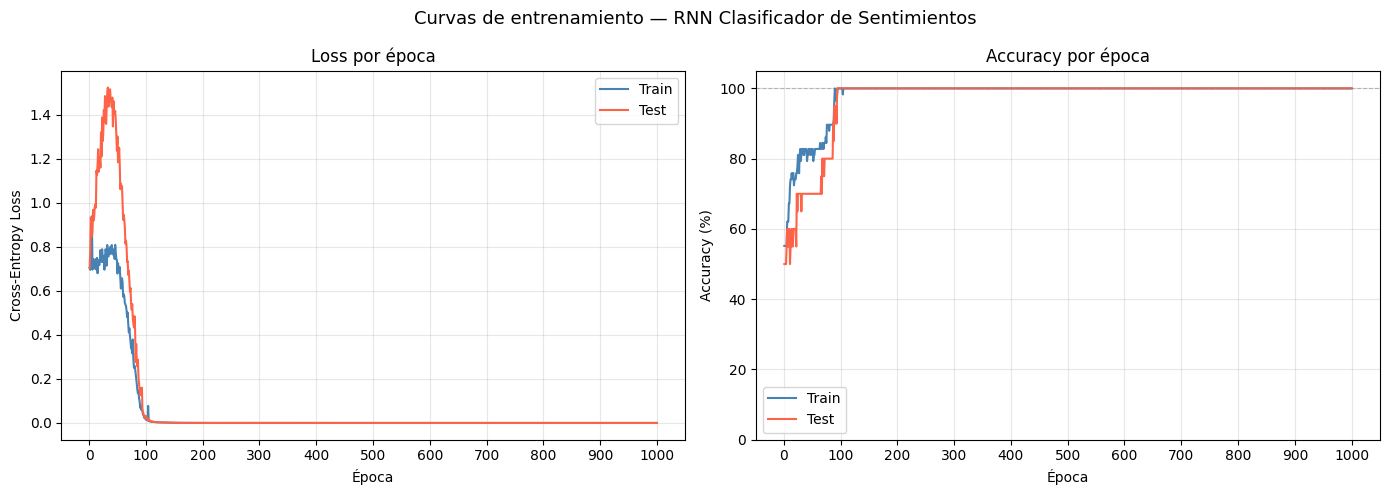

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = history['epoch']

# ── Loss ──────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs, history['train_loss'], label='Train', color='steelblue', linewidth=1.5)
ax.plot(epochs, history['test_loss'],  label='Test',  color='tomato',    linewidth=1.5)
ax.set_title('Loss por época')
ax.set_xlabel('Época')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs, [a * 100 for a in history['train_acc']], label='Train', color='steelblue', linewidth=1.5)
ax.plot(epochs, [a * 100 for a in history['test_acc']],  label='Test',  color='tomato',    linewidth=1.5)
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Accuracy por época')
ax.set_xlabel('Época')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))

plt.suptitle('Curvas de entrenamiento — RNN Clasificador de Sentimientos', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Evaluación final y predicciones

In [ ]:
model.eval()
with torch.no_grad():
    final_train_loss, final_train_acc = process_data(model, train_data, criterion)
    final_test_loss,  final_test_acc  = process_data(model, test_data,  criterion)

print('Resultados finales')
print('=' * 40)
print(f'Train → Loss: {final_train_loss:.4f} | Accuracy: {final_train_acc:.1%}')
print(f'Test  → Loss: {final_test_loss:.4f}  | Accuracy: {final_test_acc:.1%}')

Resultados finales
Train → Loss: 0.0000 | Accuracy: 100.0%
Test  → Loss: 0.0000  | Accuracy: 100.0%


In [ ]:
def predict(text: str) -> None:
    """Clasifica un texto y muestra la probabilidad de cada clase."""
    model.eval()
    words = text.split()
    unknown = [w for w in words if w not in word_to_idx]
    if unknown:
        print(f'Palabras no conocidas: {unknown}')
        return

    with torch.no_grad():
        x = text_to_tensor(text).to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=0)

    label = 'POSITIVO ✓' if probs[1] > probs[0] else 'NEGATIVO ✗'
    print(f'"{text}"')
    print(f'  → {label}  (neg: {probs[0]:.1%} | pos: {probs[1]:.1%})')


# Pruebas con frases del test set
print('── Frases del test set ──────────────────')
for frase in ['i am good', 'this is not happy', 'i am very sad', 'this is not at all bad']:
    predict(frase)

print()
print('── Frases nuevas ────────────────────────')
for frase in ['i am not sad', 'this is very good', 'i am not very happy']:
    predict(frase)

── Frases del test set ──────────────────
"i am good"
  → POSITIVO ✓  (neg: 0.0% | pos: 100.0%)
"this is not happy"
  → NEGATIVO ✗  (neg: 100.0% | pos: 0.0%)
"i am very sad"
  → NEGATIVO ✗  (neg: 100.0% | pos: 0.0%)
"this is not at all bad"
  → POSITIVO ✓  (neg: 0.0% | pos: 100.0%)

── Frases nuevas ────────────────────────
"i am not sad"
  → POSITIVO ✓  (neg: 0.0% | pos: 100.0%)
"this is very good"
  → POSITIVO ✓  (neg: 0.0% | pos: 100.0%)
"i am not very happy"
  → POSITIVO ✓  (neg: 0.0% | pos: 100.0%)
